# Tutorial 5: Rigorous Estimation and Bias Correction

In Tutorial 1, we noted that MI estimates are biased upward at small sample
sizes. In Tutorial 4, we saw how to find good parameters using sweeps.
But even with good parameters, a single `mode='estimate'` call has two
problems that make it unsuitable for scientific reporting:

1. **No error bar.** A single number with no uncertainty estimate is not a
   scientific result — it is a point estimate that could be anywhere within
   a wide confidence interval.

2. **Upward bias.** With finite data, neural MI estimators systematically
   overestimate the true MI. This is not a bug — it is a mathematical
   consequence of estimating from a limited sample. The bias scales as
   $O(1/N)$: the fewer samples you have, the larger the overestimate.

`mode='rigorous'` solves both problems with a single procedure: it trains
models on progressively smaller subsets of the data, measures how the
estimate grows as sample size shrinks, and extrapolates to the infinite-data
limit. The result is a **bias-corrected MI estimate with a confidence interval**
— a result you can report in a paper.

This tutorial demonstrates the problem, the solution, and how to recognise
when the solution itself is not reliable.

## 1. Setup: Nonlinear Data with Known MI

We use `nmi.generators.generate_nonlinear_from_latent` to create two
high-dimensional variables that share a nonlinear relationship through a
low-dimensional latent variable. We do so by using the correlated Gaussians in Tutorial 1
where there is a closed-form analytical relationship between correlation and MI, then 
we use a frozen neural network that takes the latent variables to the observable on, 
making it a harder estimation problem because of the nonlinearity, but since the neural net
can be approximated as a "sufficently smooth" function, the MI roughly stays the same.

We set the ground truth MI to **3.0 bits** spread over 10 dimensions 
and use a moderate sample size (2000 samples) that are embedded nonlinearly
 in 100 dimensional space — small enough that the finite-sample bias is 
 clearly visible and does a poor job to sample the apparent 100 dimensions,
  but large enough to sample the latent ones.

Because each sample is drawn independently (IID), we use `processor_type=None`
and `split_mode='random'`.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neural_mi as nmi

sns.set_context("talk")
np.random.seed(42)

ground_truth_mi = 3.0
n_samples = 2000

x, y = nmi.generators.generate_nonlinear_from_latent(
    n_samples=n_samples,
    latent_dim=10,
    observed_dim=100,
    mi=ground_truth_mi,
)

print(f"X shape: {x.shape}  (n_samples, observed_dim)")
print(f"Y shape: {y.shape}  (n_samples, observed_dim)")
print(f"Ground truth MI: {ground_truth_mi} bits")

X shape: torch.Size([2000, 100])  (n_samples, observed_dim)
Y shape: torch.Size([2000, 100])  (n_samples, observed_dim)
Ground truth MI: 3.0 bits


## 2. The Problem: Bias and Variance of Naive Estimates

Before running `mode='rigorous'`, let's make the problem concrete. We will
run `mode='estimate'` multiple times on different-sized subsets of the data
to directly observe how the estimate grows as sample size shrinks — this is
the finite-sample bias in action.

In [122]:
base_params = {
    'n_epochs': 100,
    'patience': 20,
    'hidden_dim': 128,
    'embedding_dim': 64,
}

sample_fractions = [1.0, 0.5, 0.25, 0.1]
naive_estimates = {}

print("--- Demonstrating finite-sample bias ---")
for frac in sample_fractions:
    n = int(n_samples * frac)
    r = nmi.run(
        x_data=x[:n],
        y_data=y[:n],
        mode='estimate',
        split_mode='random',  # IID data: random split is correct
        base_params=base_params,
    )
    naive_estimates[n] = r.mi_estimate
    print(f"  n={n:5d} samples  →  MI = {r.mi_estimate:.3f} bits  "
          f"(bias = {r.mi_estimate - ground_truth_mi:+.3f} bits)")

print(f"\nGround truth: {ground_truth_mi:.3f} bits")

--- Demonstrating finite-sample bias ---


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Run 0afa2878-b680-4bdc-8fc3-47fddefce60c_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n= 2000 samples  →  MI = 2.529 bits  (bias = -0.471 bits)


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

...

Run 3fdce7a4-0b6c-43f5-ac68-2625dfdcaae6_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n=  500 samples  →  MI = 2.397 bits  (bias = -0.603 bits)


Sequential Sweep Progress:   0%|          | 0/1 [00:00<?, ?it/s]

Run 4226f225-582d-428c-9e81-6837f2526cea_c0:   0%|          | 0/100 [00:00<?, ?it/s]

  n=  200 samples  →  MI = 1.891 bits  (bias = -1.109 bits)

Ground truth: 3.000 bits


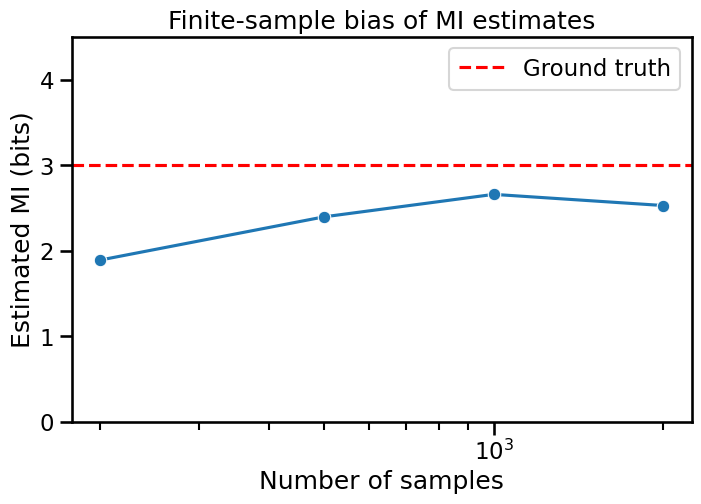

In [123]:
# plot the naive estimates
plt.figure(figsize=(8, 5))
ax = sns.lineplot(x=list(naive_estimates.keys()), y=list(naive_estimates.values()), marker='o')
ax.axhline(ground_truth_mi, color='red', linestyle='--', label="Ground truth")
ax.set_xscale('log')
ax.set_xlabel("Number of samples")
ax.set_ylabel("Estimated MI (bits)")
ax.set_title("Finite-sample bias of MI estimates")
ax.legend()
plt.ylim(0, ground_truth_mi * 1.5)
plt.show()

Note that as sample size changes, the estimated MI changes, and we don't know if there's 
an effect of the low sampling or not.
With only 10% of the data, the estimate may be substantially above -or below- the ground
truth. This is the finite-sample bias: the network finds spurious correlations
in the noise, and the smaller the dataset, the more noise there is relative
to signal. You can also see this by running the previous block few times.

This also means that a naive estimate on your full dataset could be
somewhere near the true MI — you just do not know by how much without a
correction procedure.

## 3. The Solution: `mode='rigorous'`

`mode='rigorous'` exploits the relationship between sample size and bias that
we just observed. It works as follows:

1. **Subset training.** The full dataset of $N$ samples is divided into
   $\gamma$ equal parts, and a model is trained on one part (i.e., on $N/\gamma$
   samples). This is repeated for $\gamma = 1, 2, 3, \ldots, 10$ (by default),
   with multiple independent runs at each $\gamma$.

2. **Bias as a function of $1/\gamma$.** The estimated MI at each $\gamma$ is
   plotted against $1/\gamma$. Because bias scales as $O(1/N) = O(\gamma/N)$,
   this relationship should be approximately **linear** — the MI estimate
   grows linearly as $1/\gamma$ increases (i.e., as we use less data).

3. **Extrapolation to infinite data.** A weighted linear fit to the linear
   region of the MI vs. $1/\gamma$ curve is extrapolated to $1/\gamma = 0$
   (the infinite-data limit). The y-intercept of this fit is the
   **bias-corrected MI estimate**, and the uncertainty of the fit gives the
   **confidence interval**.

By default, `mode='rigorous'` runs $\gamma = 1$ through $10$, with
$\gamma$ independent runs at each level — giving
$1 + 2 + 3 + \cdots + 10 = 55$ total training runs. This is why
`n_workers > 1` is strongly recommended.

In [ ]:
# First, store the naive estimate on the full dataset for comparison later
naive_full = naive_estimates[n_samples]

print("Running mode='rigorous' — 55 training runs by default.")
print("Using n_workers=4 to parallelise. This may take a few minutes...\n")

rigorous_results = nmi.run(
    x_data=x,
    y_data=y,
    mode='rigorous',
    split_mode='random',      # IID data: random split is correct
    base_params=base_params,
    n_workers=4,              # strongly recommended for rigorous mode
)

mi_corrected  = rigorous_results.mi_estimate
# mi_error     = confidence-interval half-width on the *fitted mean* of the
#                extrapolation.  Use this for scientific reporting.
# mi_error_pred = prediction-interval half-width — more conservative; covers
#                 where a *new individual estimate* would land.  Always >= mi_error.
mi_error      = rigorous_results.details['mi_error']
mi_error_pred = rigorous_results.details.get('mi_error_pred', None)
is_reliable   = rigorous_results.details['is_reliable']

print(f"--- Rigorous Results ---")
print(f"Ground truth MI:           {ground_truth_mi:.3f} bits")
print(f"Naive estimate (full N):   {naive_full:.3f} bits")
print(f"Corrected MI estimate:     {mi_corrected:.3f} ± {mi_error:.3f} bits  (CI half-width)")
if mi_error_pred is not None:
    print(f"Prediction interval:       {mi_corrected:.3f} ± {mi_error_pred:.3f} bits  (PI half-width)")
print(f"Fit is reliable:           {is_reliable}")

## 4. Visualising the Correction

The `results.plot()` method produces the canonical rigorous-mode figure.
Let's walk through what each element means before generating it:

- **X-axis ($\gamma$):** The number of equal parts the data was split into.
  At $\gamma = 1$, the model trained on all the data. At $\gamma = 10$,
  it trained on only one tenth.
- **Grey dots:** Individual MI estimates from each training run. There are
  $\gamma$ dots at each $\gamma$ value (one per independent run).
- **Black line:** The mean MI estimate at each $\gamma$. Notice how it rises
  as $\gamma$ increases — this is the bias curve we are correcting.
- **Red dashed line:** The weighted linear fit to the linear region of the
  black curve, extrapolated back to $\gamma = 1$ and forward to the y-axis.
- **Red star at $\gamma = 0$:** The y-intercept — our bias-corrected estimate,
  with error bars from the fit uncertainty.

We also annotate the plot with the naive estimate so the correction magnitude
is immediately visible.

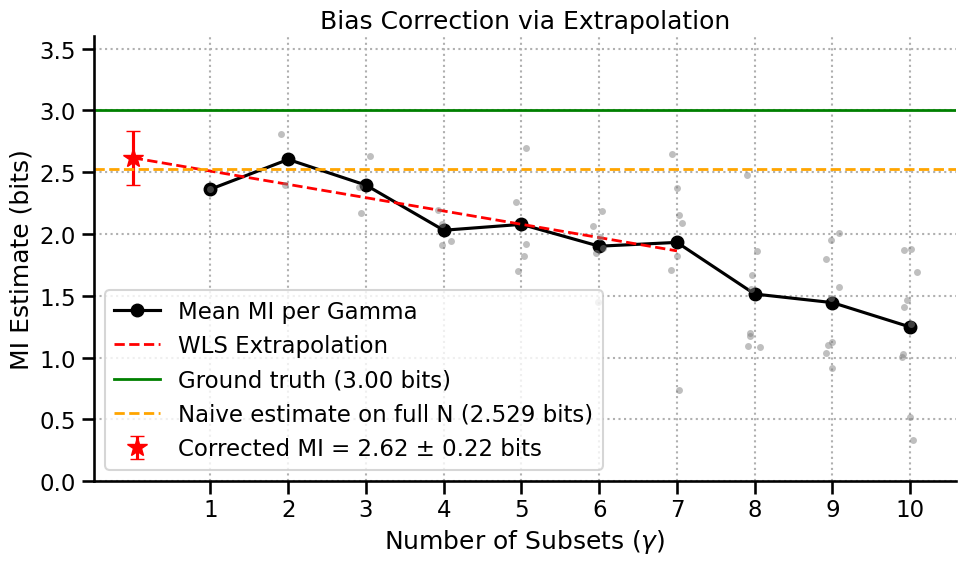

In [125]:
ax = rigorous_results.plot(show=False) # if you want to customize the plot, set show=False and then call plt.show() after customizing

# Annotate with ground truth
ax.axhline(
    y=ground_truth_mi,
    color='green', linestyle='-', linewidth=2,
    label=f'Ground truth ({ground_truth_mi:.2f} bits)'
)

# Annotate with naive estimate on full data
ax.axhline(
    y=naive_full,
    color='orange', linestyle='--', linewidth=2,
    label=f'Naive estimate on full N ({naive_full:.3f} bits)'
)

ax.set_ylim(0, max(ground_truth_mi * 1.2, mi_corrected + mi_error * 2))
ax.legend()
plt.tight_layout()
plt.show()

The orange dashed line shows where a naive estimate on the full dataset lands.
The green line shows the ground truth. The red star — the bias-corrected
estimate — should sit close to the green line, while the orange line sits
above it.

The slope of the red fit line tells you how severe the bias was: a steeper
slope means the estimator was more sensitive to sample size, which usually
indicates that the data is harder (higher-dimensional, lower SNR, or more
complex relationship between X and Y).

The `is_reliable` flag is `True` when the library found at least
`min_gamma_points` (default 5) $\gamma$ values in the linear region of the
curve. If the curve is highly non-linear (e.g., it bends sharply and then
flattens), the linear extrapolation is not trustworthy and `is_reliable`
will be `False`. Note that not every dataset will produce a reliable rigorous result. 
For example, if you have very little data, or if the relationship between X and Y is 
extremely complex for your networks, the MI vs. $1/\gamma$ curve may be strongly
 non-linear — the bias does not behave as $O(1/N)$ throughout the full range, and 
 the linear extrapolation is not valid.

When `is_reliable=False`, you have two options:

1. **Collect more data.** The most principled solution. The bias correction
   works best when you have enough samples that the estimator is operating
   in a regime where bias scales linearly with $1/N$.

2. **Simplify the model.** A very large or complex network can produce
   a strongly non-linear bias curve. Try reducing `hidden_dim`, `embedding_dim`,
   or `n_layers`, and re-run. This could work, but likely won't change the answer if you truly
   don't have enough data. A good rule of thumb is that we need to sample the low dimensional
   space well enough, so if we think we have ~10 dims (usually we don't) then we need a handful times
   as much samples, i.e., 500 samples.

In all cases: **do not report an unreliable estimate as a scientific result.**
The `is_reliable` flag exists precisely to prevent this. Treat it as a hard
gate — if it is `False`, the number should not appear in a paper without
substantial caveats.

## 5. Fine-Tuning the Rigorous Analysis

For most datasets, the defaults work well. For advanced users, three
parameters control the bias correction procedure:

- **`gamma_range`** (default `range(1, 11)`): the range of $\gamma$ values
  to test. A wider range gives more points for the linear fit but trains on
  very small subsets at high $\gamma$. A narrower range is more stable for
  small datasets.

- **`delta_threshold`** (default `0.1`): the maximum curvature allowed for
  a $\gamma$ point to be included in the linear region. Lower values are
  stricter — fewer points are included, but the fit is more linear. If
  `is_reliable=False`, try increasing this slightly.

- **`min_gamma_points`** (default `5`): the minimum number of $\gamma$ points
  required in the linear region for the fit to be considered reliable.
  Reducing this to 3 or 4 may rescue a borderline unreliable result, but
  at the cost of a less stable extrapolation.

- **`confidence_level`** (default `0.68`): the width of the confidence
  interval. `0.68` corresponds to $1\sigma$ (one standard deviation).
  Use `0.95` for a $2\sigma$ interval in contexts where that convention
  is expected.

## 7. Key Takeaways

- **`mode='estimate'` is biased upward.** Finite-sample MI estimates
  systematically overestimate the true MI. The bias grows as sample size shrinks.
  This is not a bug — it is a fundamental property of estimation from limited data.

- **`mode='rigorous'` corrects for this bias** by extrapolating the MI vs.
  $1/\gamma$ curve to the infinite-data limit. It produces a bias-corrected
  estimate with a confidence interval.

- **`mode='rigorous'` runs 55 training runs by default** (1 + 2 + … + 10).
  Always use `n_workers > 1` to parallelise.

- **`is_reliable` is a hard gate.** If it is `False`, the correction is not
  trustworthy. Collect more data, simplify the model, or adjust `gamma_range`
  before reporting any result.

- **The recommended workflow is: sweep → rigorous.**
  Use `mode='sweep'` (Tutorial 4) to find good parameters, then use
  `mode='rigorous'` with those parameters for the final estimate.

- **For IID data, use `split_mode='random'`.** For any continuous recording,
  use `split_mode='blocked'`. This applies to `mode='rigorous'` just as it
  applies to `mode='estimate'`.

## Common Mistakes

1. **Running `mode='rigorous'` with `n_workers=1`.** With 55 training runs,
   sequential execution is very slow. Always set `n_workers` to the number of
   available CPU cores. On a modern laptop, `n_workers=4` is a reasonable default.

2. **Reporting a result when `is_reliable=False`.** The `is_reliable` flag
   is not a suggestion — it is a validity check. An unreliable rigorous estimate
   can be *more* wrong than a naive estimate, because the extrapolation is being
   applied outside its valid range. Always check this flag before reporting.

3. **Using `mode='rigorous'` without first running a sweep.** Rigorous mode
   uses whatever architecture you specify in `base_params`. If the architecture
   is too small to capture the relationship, the rigorous estimate will be
   corrected but still low. Run a sweep first (Tutorial 4) to confirm that
   the architecture saturates.

4. **Interpreting the confidence interval as the total uncertainty.**
   The confidence interval from `mode='rigorous'` reflects the uncertainty of
   the linear extrapolation fit. It does not capture model uncertainty or the
   possibility that the architecture is underfitting. The two sources of
   uncertainty are complementary — use the sweep to address the latter.

## What's Next

We now have a complete workflow for reliable MI estimation: format your data
correctly (Tutorial 2), choose the right split mode (Tutorial 3), find good
parameters with a sweep (Tutorial 4), and correct for bias with rigorous
estimation (Tutorial 5).

In **Tutorial 6**, we move from asking "how much information is shared?" to
asking "when is it shared, and in which direction?" We introduce three
temporally-oriented analysis modes: `mode='lag'` to find transmission delays,
`mode='precision'` to measure the timescale of spike-timing codes, and
`mode='transfer'` to estimate directed information flow between brain regions.